# Title

In [3]:
import pandas as pd
import pickle
import os
import json
import spacy
from spacy import displacy
from matplotlib import pyplot as plt
from utils import return_LLM_entities_ids, return_LLM_entities_ids_en
from tqdm import tqdm
from acl_anthology import Anthology
import re

## Load the data

In [4]:
data_folder = "data/"
analyzed_jeptalnrecital_file = "analyzed-jeptalnrecital-papers.pkl"

with open(os.path.join(data_folder, analyzed_jeptalnrecital_file), "rb") as f:
    df = pickle.load(f)
    
print(df.shape)

(737, 15)


## Anthropomorphisation clues

### Lexical clues

In [5]:
## AnthroSet
anthroset_clues_fr_verbs = set(["penser", "attendre", "espérer", "prédire", "rêver", "imaginer", "croire",
                            "savoir", "connaître", "souvenir", "reconnaître", "mémoriser", "retenir", "identifier",
                            "classer", "différencier", "distinguer",
                            "déduire", "conclure", "raisonner", "justifier", "comprendre", "interpréter", "analyser",
                            "inférer", "conseiller", "préférer", "sélectioner", "choisir", "décider", "déterminer",
                            "résoudre", "planifier", "coordonner", "stratégiser", "élaborer", "tricher", "enfreindre",
                            "suivre", "réussir", "accomplir", "communiquer", "parler", "discuter", "dire", "expliquer",
                            "apprendre", "enseigner", "demander", "suggérer", "aider", "contribuer", "assister", 
                            "mentir", "collaborer", "manipuler", "insulter", "tromper", "partenaire", "adversaire",
                            "superviser", "voir", "entendre", "percevoir", "sentir", 
                     ])

# taxonomie AnthroSet paper + noms dans 'genitive_NPs_positive.csv'
anthroset_clues_fr_nouns = set(["conscience", "savoir", "souvenir", "connaissance","difficulté", "assistance", "aide",
                            "feedback", "réaction", "idée", "perspicacité", "confiance", "manager", "employé", "employée",
                            "professeur", "tuteur", "étudiant", "compagnon", "émotion", "poésie", "art", "artiste", "poète",
                            "humour", "ironie", "décision", "malentendu", "incompréhension", "interprétation", "contresens", 
                            "action", "mensonge", "assistant", "raisonnement", "capacité", "tendance", "compétence",
                            "personnalité", "force", "coopération", "coordination", "manipulation", "maîtrise", "écriture",
                            "désir", "délibération", "comportement","esprit",
])

# taxonomie AnthroSet paper + adjectifs dans 'adjectives_positive.csv'
anthroset_clues_fr_adjectives = set(["conscient", "autonome", "indépendant", "créatif",
                                 "communicatif", "responsable", "expert", 
                                 "conseiller", "honnête", "sincère", "malhonnête", "trompeur", 
                                 "attentionné", "attentif", "amical", "sensible",
                                 "vulnérable", "créatif","artistique", "drôle", "aveugle", "sourd",
                                 "intelligent", "réactif", "confiant", "aligné", "malveillant", "manipulateur",
                                 "désorienté", "confus", "capable", "compétent",
    
])

In [6]:
# Other clues (inspired from Inie et al. 2026 + empirical observations)
clues_fr_verbs = set([
    "oublier", "halluciner", "compatir", "préoccuper", "inquiéter", "répondre", "confondre",
    "prévoir", "créer", "imiter", "simuler", "incarner", "capturer",
]).union(anthroset_clues_fr_verbs)

clues_fr_nouns = set([
    "intention", "préférence", "valeur", "morale", "psychologue", "hallucination", "intelligence", "capacité", "compétence", 
    "explication", "suggestion", "hallucination", "oubli", "préoccupation", "inquiétude", "réponse", "confusion", "création", "imitation",
    "simulation", "culture"
    "docteur", "médecin", "neurone", "compréhension", "décision", "analyse", "prévision", "lien", "sentiment", "thérapeute", "éditeur"
]).union(anthroset_clues_fr_nouns)

clues_fr_adjectives = set(["relecteur","fatigué", "intelligent", "empathique", "thérapeutique", "français", "natif", "étranger",
                          "fiable", "équitable",]).union(anthroset_clues_fr_adjectives)

### Dicovalence

In [7]:
dicovalence_file = "dicovalence_entries.json"

with open(os.path.join(data_folder, dicovalence_file), "r", encoding = "utf-8") as f:
    dicovalence = json.load(f)

In [8]:
def get_hum_score_for_synt_fn(verb, dicovalence, synt_fn):
    score = -1
    if verb in dicovalence.keys():
        key = f"hum_score_{synt_fn}"
        if key in dicovalence[verb].keys():
            score = dicovalence[verb][key]
    return score

In [9]:
get_hum_score_for_synt_fn("penser", dicovalence, "subj")

1.0

In [10]:
get_hum_score_for_synt_fn("manger", dicovalence, "subj")

0.5

### Verbes dont des entités-LLM sont le sujet

Articles dont au moins un verbe a été identifié en association avec une entité-LLM comme sujet :

In [11]:
vsubj_df = df[df["verb_subj"].apply(lambda x: x!= [])]
print(vsubj_df.shape[0])

86


Nombres de verbes concernés :

In [12]:
total_verb_occ = 0

for i, row in vsubj_df.iterrows():
    total_verb_occ += len(row["verb_subj"])

print(total_verb_occ)

118


Extraction des verbes pour les confronter aux indices d'anthropomorphosisation :

In [13]:
verb_data = {}

for i, row in vsubj_df.iterrows():
    row_verbs = set()
    
    for llm_entity_id, verb_id in row["verb_subj"]:

        verb_lemma = row["analyzed_text"][verb_id].lemma_
        llm_entity_lemma = row["analyzed_text"][llm_entity_id].lemma_

        if verb_lemma in verb_data.keys():
            
            verb_data[verb_lemma]["total_occ"] += 1
            verb_data[verb_lemma]["all_occ_pointers"].append((row["full_id"], llm_entity_id, verb_id))
            
            if verb_lemma not in row_verbs:
                verb_data[verb_lemma]["art_occ"] += 1
                row_verbs.add(verb_lemma)
        else:
            verb_data[verb_lemma] = {
                "total_occ" : 1,
                "art_occ" : 1,
                "hum_score_subj" : get_hum_score_for_synt_fn(verb_lemma, dicovalence, "subj"),
                "all_occ_pointers" : [(row["full_id"], llm_entity_id, verb_id)],
            }

Nombre de verbes uniques relevés :

In [14]:
print(len(verb_data))

67


In [15]:
verb_subj_df = pd.DataFrame(verb_data).T

verb_subj_df["anthroset_clue"] = [v in anthroset_clues_fr_verbs for v, row in verb_subj_df.iterrows()]
verb_subj_df["extended_clue"] = [v in clues_fr_verbs for v, row in verb_subj_df.iterrows()]

In [16]:
verb_subj_df

,total_occ,art_occ,hum_score_subj,all_occ_pointers,anthroset_clue,extended_clue
connaître,2,2,1.0,"[(2023.jeptalnrecital-coria.11, 25, 29), (2022...",True,True
parvenir,1,1,0.333333,"[(2023.jeptalnrecital-coria.11, 92, 95)]",False,False
recommander,1,1,1.0,"[(2025.jeptalnrecital-iaedu.3, 92, 101)]",False,False
permettre,4,4,0.5,"[(2024.jeptalnrecital-taln.23, 45, 52), (2022....",False,False
améliorer,1,1,0.0,"[(2025.jeptalnrecital-taln.47, 153, 159)]",False,False
...,...,...,...,...,...,...
traire,1,1,1.0,"[(2025.jeptalnrecital-taln.22, 156, 158)]",False,False
capturer,1,1,1.0,"[(2025.jeptalnrecital-taln.2, 63, 64)]",False,True
peiner,1,1,0.666667,"[(2023.jeptalnrecital-long.21, 12, 18)]",False,False
illustre,1,1,-1,"[(2025.jeptalnrecital-iaedu.8, 56, 57)]",False,False


In [17]:
verb_subj_df[verb_subj_df["anthroset_clue"]]

,total_occ,art_occ,hum_score_subj,all_occ_pointers,anthroset_clue,extended_clue
connaître,2,2,1.0,"[(2023.jeptalnrecital-coria.11, 25, 29), (2022...",True,True
distinguer,1,1,0.2,"[(2024.jeptalnrecital-trad.8, 508, 514)]",True,True
différencier,1,1,0.166667,"[(2025.jeptalnrecital-taln.22, 121, 122)]",True,True


In [18]:
verb_subj_df[verb_subj_df["extended_clue"]]

,total_occ,art_occ,hum_score_subj,all_occ_pointers,anthroset_clue,extended_clue
connaître,2,2,1.0,"[(2023.jeptalnrecital-coria.11, 25, 29), (2022...",True,True
distinguer,1,1,0.2,"[(2024.jeptalnrecital-trad.8, 508, 514)]",True,True
différencier,1,1,0.166667,"[(2025.jeptalnrecital-taln.22, 121, 122)]",True,True
capturer,1,1,1.0,"[(2025.jeptalnrecital-taln.2, 63, 64)]",False,True


In [19]:
# with open("analysis/verb-subj-list.pkl", "wb") as f:
#     pickle.dump(verb_subj_df, f)

In [20]:
verb_subj_df.sort_values(by = "hum_score_subj", ascending = False).head(15)

,total_occ,art_occ,hum_score_subj,all_occ_pointers,anthroset_clue,extended_clue
connaître,2,2,1.0,"[(2023.jeptalnrecital-coria.11, 25, 29), (2022...",True,True
exceller,1,1,1.0,"[(2025.jeptalnrecital-coria.13, 57, 64)]",False,False
exploiter,1,1,1.0,"[(2022.jeptalnrecital-taln.37, 162, 164)]",False,False
favoriser,2,2,1.0,"[(2024.jeptalnrecital-taln.5, 92, 93), (2022.j...",False,False
afficher,1,1,1.0,"[(2024.jeptalnrecital-trad.8, 320, 323)]",False,False
respecter,2,2,1.0,"[(2022.jeptalnrecital-demo.2, 71, 73), (2025.j...",False,False
introduire,1,1,1.0,"[(2025.jeptalnrecital-taln.30, 68, 71)]",False,False
évaluer,2,2,1.0,"[(2025.jeptalnrecital-evalllm.7, 73, 74), (202...",False,False
hériter,1,1,1.0,"[(2025.jeptalnrecital-recital.11, 80, 81)]",False,False
négliger,1,1,1.0,"[(2022.jeptalnrecital-taln.26, 73, 74)]",False,False


In [21]:
verb_subj_df.sort_values(by = "total_occ", ascending = False)

,total_occ,art_occ,hum_score_subj,all_occ_pointers,anthroset_clue,extended_clue
pouvoir,14,13,0.5,"[(2021.jeptalnrecital-recital.1, 56, 63), (202...",False,False
obtenir,9,9,1.0,"[(2024.jeptalnrecital-jep.17, 117, 120), (2024...",False,False
montrer,5,5,0.666667,"[(2024.jeptalnrecital-trad.8, 260, 262), (2024...",False,False
avoir,5,5,0.454545,"[(2020.jeptalnrecital-taln.15, 165, 170), (202...",False,False
permettre,4,4,0.5,"[(2024.jeptalnrecital-taln.23, 45, 52), (2022....",False,False
...,...,...,...,...,...,...
susciter,1,1,0.0,"[(2023.jeptalnrecital-international.9, 54, 58)]",False,False
exceller,1,1,1.0,"[(2025.jeptalnrecital-coria.13, 57, 64)]",False,False
affine,1,1,-1,"[(2025.jeptalnrecital-coria.7, 105, 106)]",False,False
transformer,1,1,0.333333,"[(2025.jeptalnrecital-recital.11, 23, 31)]",False,False


In [22]:
for v, row in verb_subj_df.sort_values(by = "hum_score_subj", ascending = False).iterrows():
    score = row["hum_score_subj"]
    pointers = row["all_occ_pointers"]
        
    print(v, score)
    for full_id, llm_ent_id, verb_id in pointers:
        doc = df[df["full_id"] == full_id]["analyzed_text"].values[0]
        
        min_id = min([llm_ent_id, verb_id])
        max_id = max([llm_ent_id, verb_id])

        start = max(0, min_id - 10)
        end = min(len(doc), max_id + 10)
            
        ex = doc[start:end]
        print(ex, f"({full_id})\n")
    print()

connaître 1.0
direction de recherche.
Ces dernières années, les modèles de langue ont connu une évolution galopante grâce à l’augmentation de la (2023.jeptalnrecital-coria.11)

Low-resource Multilingual Epidemic Surveillance).
Les modèles de langues pré-entraînés connaissent un très grand succès en TAL, en particulier (2022.jeptalnrecital-taln.34)


exceller 1.0
chercheurs en intelligence artificielle. Cependant, bien que les Modèles de Langue Préentraînés (PLMs) excellent dans diverses tâches de TAL, leur efficacité dans (2025.jeptalnrecital-coria.13)


exploiter 1.0
Nos expériences sur le corpus ACE 2005 démontrent que le modèle proposé exploite correctement les informations sur les entités dans le cadre (2022.jeptalnrecital-taln.37)


favoriser 1.0
pour mettre au jour des biais. Ainsi, les modèles favorisent largement la génération de masculin : le genre masculin (2024.jeptalnrecital-taln.5)

équivalent pour un groupe favorisé. Nous montrons que quatre modèles de langue favorisent l

### Verbes dont l'entité-LLM est un complément ou objet

In [23]:
vcompl_df = df[df["verb_compl"].apply(lambda x: x!= [])]
print(vcompl_df.shape[0])

127


In [24]:
total_verb_occ = 0

for i, row in vcompl_df.iterrows():
    total_verb_occ += len(row["verb_compl"])

print(total_verb_occ)

184


In [25]:
vcompl_data = {}

for i, row in vcompl_df.iterrows():
    row_verbs = set()
    
    for llm_entity_id, verb_id in row["verb_compl"]:

        verb_lemma = row["analyzed_text"][verb_id].lemma_
        llm_entity_lemma = row["analyzed_text"][llm_entity_id].lemma_
        
        if verb_lemma in vcompl_data.keys():
            
            vcompl_data[verb_lemma]["total_occ"] += 1
            vcompl_data[verb_lemma]["all_occ_pointers"].append((row["full_id"], llm_entity_id, verb_id))

            if verb_lemma not in row_verbs:
                vcompl_data[verb_lemma]["art_occ"] += 1
                row_verbs.add(verb_lemma)
        else:
            vcompl_data[verb_lemma] = {
                "total_occ" : 1,
                "art_occ" : 1,
                "hum_score_obj" : get_hum_score_for_synt_fn(verb_lemma, dicovalence, "obj"),
                "all_occ_pointers" : [(row["full_id"], llm_entity_id, verb_id)],
            }

In [26]:
print(len(vcompl_data))

65


In [27]:
verb_compl_df = pd.DataFrame(vcompl_data).T
verb_compl_df["anthroset_clue"] = [v in anthroset_clues_fr_verbs for v, row in verb_compl_df.iterrows()]
verb_compl_df["extended_clue"] = [v in clues_fr_verbs for v, row in verb_compl_df.iterrows()]

In [28]:
verb_compl_df[verb_compl_df["anthroset_clue"]]

,total_occ,art_occ,hum_score_obj,all_occ_pointers,anthroset_clue,extended_clue
demander,1,1,0.571429,"[(2025.jeptalnrecital-taln.39, 129, 127)]",True,True
identifier,1,1,0.0,"[(2024.jeptalnrecital-taln.37, 118, 115)]",True,True


In [29]:
verb_compl_df[verb_compl_df["extended_clue"]]

,total_occ,art_occ,hum_score_obj,all_occ_pointers,anthroset_clue,extended_clue
demander,1,1,0.571429,"[(2025.jeptalnrecital-taln.39, 129, 127)]",True,True
identifier,1,1,0.0,"[(2024.jeptalnrecital-taln.37, 118, 115)]",True,True


In [30]:
with open("analysis/verb-objcompl-list.pkl", "wb") as f:
    pickle.dump(verb_compl_df, f)

In [31]:
verb_compl_df[verb_compl_df["hum_score_obj"] >= 0.5].shape[0]

8

In [32]:
sorted(list(verb_compl_df[verb_compl_df["hum_score_obj"] == 1].index))

['permettre']

In [33]:
verb_compl_df.head()

,total_occ,art_occ,hum_score_obj,all_occ_pointers,anthroset_clue,extended_clue
entraîner,12,11,0.428571,"[(2023.jeptalnrecital-coria.11, 115, 113), (20...",False,False
évaluer,10,10,0.0,"[(2025.jeptalnrecital-coria.1, 105, 103), (202...",False,False
refléter,1,1,0.0,"[(2024.jeptalnrecital-taln.9, 35, 32)]",False,False
permettre,2,2,1.0,"[(2025.jeptalnrecital-trad.18, 133, 128), (202...",False,False
soumettre,1,1,0.75,"[(2025.jeptalnrecital-trad.18, 210, 204)]",False,False


In [34]:
verb_compl_df.sort_values(by = "total_occ", ascending = False)

,total_occ,art_occ,hum_score_obj,all_occ_pointers,anthroset_clue,extended_clue
baser,21,16,0.0,"[(2022.jeptalnrecital-taln.10, 88, 84), (2022....",False,False
utiliser,21,19,0.0,"[(2025.jeptalnrecital-trad.12, 86, 84), (2022....",False,False
entraîner,12,11,0.428571,"[(2023.jeptalnrecital-coria.11, 115, 113), (20...",False,False
évaluer,10,10,0.0,"[(2025.jeptalnrecital-coria.1, 105, 103), (202...",False,False
comparer,8,8,0.0,"[(2024.jeptalnrecital-jep.24, 75, 71), (2025.j...",False,False
...,...,...,...,...,...,...
aboutir,1,1,0.0,"[(2020.jeptalnrecital-recital.3, 78, 75)]",False,False
varier,1,1,0.0,"[(2024.jeptalnrecital-trad.8, 430, 426)]",False,False
injecter,1,1,0.25,"[(2023.jeptalnrecital-long.10, 87, 84)]",False,False
enrichir,1,1,0.333333,"[(2023.jeptalnrecital-long.10, 172, 169)]",False,False


In [35]:
verb_compl_df.sort_values(by = "hum_score_obj", ascending = False)

,total_occ,art_occ,hum_score_obj,all_occ_pointers,anthroset_clue,extended_clue
permettre,2,2,1.0,"[(2025.jeptalnrecital-trad.18, 133, 128), (202...",False,False
soumettre,1,1,0.75,"[(2025.jeptalnrecital-trad.18, 210, 204)]",False,False
demander,1,1,0.571429,"[(2025.jeptalnrecital-taln.39, 129, 127)]",True,True
surpasser,6,6,0.5,"[(2025.jeptalnrecital-taln.30, 148, 146), (202...",False,False
intéresser,2,2,0.5,"[(2025.jeptalnrecital-trad.14, 147, 144), (202...",False,False
...,...,...,...,...,...,...
réentraîner,1,1,-1,"[(2025.jeptalnrecital-iaedu.5, 78, 76)]",False,False
démythifier,1,1,-1,"[(2025.jeptalnrecital-iaedu.12, 259, 257)]",False,False
guide,1,1,-1,"[(2025.jeptalnrecital-coria.14, 129, 127)]",False,False
présente,2,2,-1,"[(2024.jeptalnrecital-taln.43, 23, 21), (2025....",False,False


In [36]:
for v, row in verb_compl_df.sort_values(by = "hum_score_obj", ascending = False).iterrows():
    score = row["hum_score_obj"]
    pointers = row["all_occ_pointers"]

        
    print(v, score)
    for full_id, llm_ent_id, verb_id in pointers:
        doc = df[df["full_id"] == full_id]["analyzed_text"].values[0]
        
        min_id = min([llm_ent_id, verb_id])
        max_id = max([llm_ent_id, verb_id])

        start = max(0, min_id - 10)
        end = min(len(doc), max_id + 10)
            
        ex = doc[start:end]
        print(ex, f"({full_id})")
    print()

permettre 1.0
. Pour déterminer si l’utilisation d’un tel langage permet tout de même au modèle de langue de déterminer l’égilibilité du patient pour (2025.jeptalnrecital-trad.18)
utilisant un outil d’extraction de chaînes de caractères, permettant au LLM d’extraire une réponse plutôt que de la générer (2025.jeptalnrecital-coria.18)

soumettre 0.75
labellisés « éligible » ou « exclu ». Nous soumettons des amorces à plusieurs grands modèles de langue, et obtenons un score F1 compris (2025.jeptalnrecital-trad.18)

demander 0.5714285714285714
langue (LLMs). Les résumés sont évalués en demandant aux LLMs de répondre à ces questions avant (i)de sélectionner (2025.jeptalnrecital-taln.39)

surpasser 0.5
que ces heuristiques améliorent les performances. Les heuristiques séquentielles surpassent les modèles hiérarchiques sur deux des trois jeux de données. (2025.jeptalnrecital-taln.30)
, ce qui améliore grandement ses performances et le fait surpasser significativement notre modèle de base, un 

### Adjectifs et attributs du sujet

In [37]:
adj_df = df[df["adj_attrsubj"].apply(lambda x: x!= [])]
print(adj_df.shape[0])

172


In [38]:
adj_attr_mentions = 0

for i, row in adj_df.iterrows():
    adj_attr_mentions += len(row["adj_attrsubj"])

print(adj_attr_mentions)

379


In [39]:
adj_data = {}

for i, row in adj_df.iterrows():
    row_adjs = set()
    
    for llm_entity_id, adj_id in row["adj_attrsubj"]:

        adj_lemma = row["analyzed_text"][adj_id].lemma_
        llm_entity_lemma = row["analyzed_text"][llm_entity_id].lemma_


        if adj_lemma in adj_data.keys():
            
            adj_data[adj_lemma]["total_occ"] += 1
            adj_data[adj_lemma]["all_occ_pointers"].append((row["full_id"], llm_entity_id, adj_id))


            if adj_lemma not in row_verbs:
                adj_data[adj_lemma]["art_occ"] += 1
                row_adjs.add(adj_lemma)
        else:
            adj_data[adj_lemma] = {
                "total_occ" : 1,
                "art_occ" : 1,
                "all_occ_pointers" : [(row["full_id"], llm_entity_id, adj_id)],
            }

In [40]:
print(len(adj_data))

101


In [41]:
adj_df = pd.DataFrame(adj_data).T

adj_df["anthroset_clue"] = [a in anthroset_clues_fr_adjectives for a, row in adj_df.iterrows()]
adj_df["extended_clue"] = [a in clues_fr_adjectives for a, row in adj_df.iterrows()]

In [42]:
adj_df[adj_df["anthroset_clue"]]

,total_occ,art_occ,all_occ_pointers,anthroset_clue,extended_clue
capable,8,8,"[(2024.jeptalnrecital-jep.19, 127, 129), (2024...",True,True
artistique,1,1,"[(2020.jeptalnrecital-demos.11, 4, 6)]",True,True
confiant,1,1,"[(2025.jeptalnrecital-taln.46, 93, 95)]",True,True


In [43]:
sorted(list(adj_df[adj_df["extended_clue"]].index))

['artistique',
 'capable',
 'confiant',
 'fiable',
 'français',
 'natif',
 'équitable',
 'étranger']

In [44]:
adj_df.head()

,total_occ,art_occ,all_occ_pointers,anthroset_clue,extended_clue
actuel,4,4,"[(2023.jeptalnrecital-coria.11, 92, 93), (2023...",False,False
conversationnel,13,13,"[(2024.jeptalnrecital-jep.19, 45, 46), (2021.j...",False,False
capable,8,8,"[(2024.jeptalnrecital-jep.19, 127, 129), (2024...",True,True
français,4,4,"[(2024.jeptalnrecital-taln.9, 35, 38), (2024.j...",False,True
grand,88,88,"[(2025.jeptalnrecital-trad.18, 210, 209), (202...",False,False


In [45]:
adj_df.sort_values(by = "total_occ", ascending = False)

,total_occ,art_occ,all_occ_pointers,anthroset_clue,extended_clue
grand,88,88,"[(2025.jeptalnrecital-trad.18, 210, 209), (202...",False,False
neuronal,25,25,"[(2022.jeptalnrecital-taln.19, 61, 62), (2023....",False,False
génératif,20,20,"[(2025.jeptalnrecital-taln.34, 100, 103), (202...",False,False
conversationnel,13,13,"[(2024.jeptalnrecital-jep.19, 45, 46), (2021.j...",False,False
artificiel,13,13,"[(2025.jeptalnrecital-iaedu.4, 3, 4), (2025.je...",False,False
...,...,...,...,...,...
hybride,1,1,"[(2025.jeptalnrecital-mlpllm.5, 178, 179)]",False,False
coûteux,1,1,"[(2025.jeptalnrecital-mlpllm.3, 60, 64)]",False,False
fin,1,1,"[(2025.jeptalnrecital-mlpllm.5, 132, 133)]",False,False
artistique,1,1,"[(2020.jeptalnrecital-demos.11, 4, 6)]",True,True


In [46]:
with open("analysis/ajd-attrsubj-list.pkl", "wb") as f:
    pickle.dump(adj_df, f)

In [47]:
for a, row in adj_df.iterrows():
    pointers = row["all_occ_pointers"]
    print(a)
    print(a in anthroset_clues_fr_adjectives)
    for full_id, llm_ent_id, adj_id in pointers:
        doc = df[df["full_id"] == full_id]["analyzed_text"].values[0]
        
        min_id = min([llm_ent_id, adj_id])
        max_id = max([llm_ent_id, adj_id])

        start = max(0, min_id - 10)
        end = min(len(doc), max_id + 10)
            
        ex = doc[start:end]
        print(ex, f"({full_id})")
    print()

actuel
False
des données numériques soit devenu un paradigme courant, les modèles actuels ne parviennent pas à effectuer des calculs de manière (2023.jeptalnrecital-coria.11)
prévention de plagiat. Plusieurs études ont montré que les modèles de détection actuels ont une précision élevée, en donnant l’impression (2023.jeptalnrecital-arts.12)
langues des signes, et ii) d’améliorer les modèles actuels et leur permettre de rendre compte de la phonologie (2020.jeptalnrecital-jep.48)
Tandis que cette implémentation requiert des ajustements minimes dans les modèles formels actuels, son impact quant à la théorie générale de (2020.jeptalnrecital-jep.48)

conversationnel
False
, les rendant souvent inadaptés à leur utilisation dans des agents conversationnels incarnés ou dans d’autres domaines de recherche comme (2024.jeptalnrecital-jep.19)
Améliorer un agent conversationnel : prendre en compte à la volée des retours (2021.jeptalnrecital-recital.1)
en profitant de l’expérience passée du système.

ingénieurs en informatique visant à encadrer l’usage de l’Intelligence Artificielle Générative (IAG) dans le cadre d’une (2025.jeptalnrecital-iaedu.7)

auto-supervisé
False
Vers l’entraînement de modèles de reconnaissance automatique de la parole auto-supervisés équitables sans étiquettes démographiques.
Malgré des avancées (2025.jeptalnrecital-taln.47)
publiquement distribués. Dans ces travaux, nous préentraînons des modèles de parole auto-supervisés multilingues à partir de langues subsahariennes exclusivement. Nous (2024.jeptalnrecital-jep.17)
justifiant le besoin de méthodes automatiques et objectives. Un modèle auto-supervisé basé sur Wav2Vec2 est proposé pour la classification de (2024.jeptalnrecital-jep.27)
auto-supervisés multilingues préentraînés avec des données écologiques.
Les modèles auto-supervisés omnilingues de traitement de la parole sont adaptables mais (2025.jeptalnrecital-taln.24)
éclairent ainsi sur les véritable capacités linguistiques et paralinguistiques des mod

Tandis que cette implémentation requiert des ajustements minimes dans les modèles formels actuels, son impact quant à la théorie générale (2020.jeptalnrecital-jep.48)

différent
False
. Dans ce travail, nous estimons la capacité de différents modèles de type transformers pré-entraînés (BERT, RoBERTa, (2021.jeptalnrecital-taln.20)
l’évaluation de l’utilité des nouvelles idées pour les différents modèles de RI neuronaux. Cela ralentit l’adoption de (2023.jeptalnrecital-coria.19)

faible
False
plus performant sur les deux tâches, tandis que les modèles XLNet et ALBERT sont les plus faibles. Par ailleurs, les performances de la plupart (2021.jeptalnrecital-taln.20)

confiant
True
sycophantie. Les stratégies de décodage peuvent également rendre les modèles trop confiants et enclins à attribuer des probabilités aux résultats incorrects (2025.jeptalnrecital-taln.46)

utile
False
. Ce résultat indique une piste prometteuse pour rendre ces modèles massivement multilingues utiles pour de nouveau

In [48]:
sorted(adj_df.index)

['actuel',
 'adaptable',
 'ancien',
 'antérieur',
 'artificiel',
 'artistique',
 'auto-régressif',
 'auto-supervisé',
 'autre',
 'avancé',
 'biomédical',
 'bon',
 'capable',
 'causal',
 'classique',
 'compact',
 'confiant',
 'contextuel',
 'conversationnel',
 'convolutif',
 'coûteux',
 'différent',
 'disponible',
 'dominant',
 'dédier',
 'efficace',
 'existant',
 'explicable',
 'faible',
 'fameux',
 'fiable',
 'fin',
 'formel',
 'français',
 'frugal',
 'grand',
 'gros',
 'généraliste',
 'génératif',
 'générique',
 'hiérarchique',
 'hybride',
 'idéal',
 'indispensable',
 'individuel',
 'initial',
 'intéressant',
 'inutilisé',
 'large',
 'linguistique',
 'léger',
 'meilleur',
 'mini',
 'mono-',
 'monolingue',
 'multi-média',
 'multi-tâche',
 'multilingue',
 'multimodal',
 'même',
 'natif',
 'neuronal',
 'nombreux',
 'non-supervisé',
 'nouveau',
 'omnilingue',
 'omniprésent',
 'originel',
 'performant',
 'petit',
 'phonologique',
 'premier',
 'principal',
 'pré-entraîné',
 'prédictif',
 '

In [49]:
adj = "étranger"

for full_id, llm_ent_id, adj_id in adj_df.loc[[adj]]["all_occ_pointers"].values[0]:
    doc = df[df["full_id"] == full_id]["analyzed_text"].values[0]
    
    min_id = min([llm_ent_id, adj_id])
    max_id = max([llm_ent_id, adj_id])

    start = max(0, min_id - 10)
    end = min(len(doc), max_id + 10)
        
    ex = doc[start:end]
    print(ex, f"({full_id})")
    print()

de ces trois modèles SSL, et de deux autres modèles SSL étrangers directement affinés, sur une tâche de reconnaissance de (2024.jeptalnrecital-taln.45)



In [50]:
df[df["full_id"] == "2023.jeptalnrecital-arts.12"]["analyzed_text"].values[0]

La détection de textes générés par des modèles de langue : une tâche complexe? Une étude sur des textes académiques.
L’émergence de modèles de langage très puissants tels que GPT-3 a sensibilisé les chercheurs à la problématique de la détection de textes académiques générés automatiquement, principalement dans un souci de prévention de plagiat. Plusieurs études ont montré que les modèles de détection actuels ont une précision élevée, en donnant l’impression que la tâche soit résolue. Cependant, nous avons observé que les ensembles de données utilisés pour ces expériences contiennent des textes générés automatiquement à partir de modèles pré-entraînés. Une utilisation plus réaliste des modèles de langage consisterait à effectuer un fine-tuning sur un texte écrit par un humain pour compléter les parties manquantes. Ainsi, nous avons constitué un corpus de textes générés de manière plus réaliste et mené des expériences avec plusieurs modèles de classification. Nos résultats montrent que l

### Compléments nominaux

In [51]:
nmod_df = df[df["noun_compound"].apply(lambda x: x!= [])]
print(nmod_df.shape[0])

31


In [52]:
count = 0

for i, row in nmod_df.iterrows():
    count += len(row["noun_compound"])

print(count)

51


In [53]:
nmod_data = {}

for i, row in nmod_df.iterrows():
    row_nmods = set()
    
    for llm_entity_id, nmod_id in row["noun_compound"]:

        nmod_lemma = row["analyzed_text"][nmod_id].lemma_
        llm_entity_lemma = row["analyzed_text"][llm_entity_id].lemma_

        if nmod_lemma in nmod_data.keys():
            
            nmod_data[nmod_lemma]["total_occ"] += 1
            nmod_data[nmod_lemma]["all_occ_pointers"].append((row["full_id"], llm_entity_id, nmod_id))
           
            if nmod_lemma not in row_nmods:
                nmod_data[nmod_lemma]["art_occ"] += 1
                row_nmods.add(nmod_lemma)
        else:
            nmod_data[nmod_lemma] = {
                "total_occ" : 1,
                "art_occ" : 1,
                "all_occ_pointers" : [(row["full_id"], llm_entity_id, nmod_id)],
            }

In [54]:
print(len(nmod_data))

32


In [55]:
nmod_df = pd.DataFrame(nmod_data).T

nmod_df["anthroset_clue"] = [n in anthroset_clues_fr_nouns for n, row in nmod_df.iterrows()]
nmod_df["extended_clue"] = [n in clues_fr_nouns for n, row in nmod_df.iterrows()]

In [56]:
nmod_df[nmod_df["anthroset_clue"]]

,total_occ,art_occ,all_occ_pointers,anthroset_clue,extended_clue


In [57]:
nmod_df[nmod_df["extended_clue"]]

,total_occ,art_occ,all_occ_pointers,anthroset_clue,extended_clue
réponse,1,1,"[(2022.jeptalnrecital-taln.10, 166, 170)]",False,True


In [58]:
nmod_df.head()

,total_occ,art_occ,all_occ_pointers,anthroset_clue,extended_clue
-,12,8,"[(2022.jeptalnrecital-taln.10, 166, 169), (202...",False,False
réponse,1,1,"[(2022.jeptalnrecital-taln.10, 166, 170)]",False,True
vanille,1,1,"[(2023.jeptalnrecital-coria.14, 248, 250)]",False,False
base,1,1,"[(2024.jeptalnrecital-jep.17, 117, 119)]",False,False
8b.,1,1,"[(2025.jeptalnrecital-taln.6, 210, 212)]",False,False


In [59]:
with open("analysis/noun-mod-list.pkl", "wb") as f:
    pickle.dump(nmod_df, f)

In [60]:
nmod_df.index

Index(['-', 'réponse', 'vanille', 'base', '8b.', 'gpt-2', 'moderation', 'opus',
       'détecteur', 'pivot', 'fin', 'enbout', 'gpt', 't5', 'cnn',
       'transformeur', '8b', 'ssl', 'wav2vec2', 'seq2seq', 'pro', 'l_', '14b',
       'llm', '70b', 'r1', '27b', 'encodeur', 'pre', 'bio', 'tâche',
       'instruct'],
      dtype='str')

In [61]:
for n, row in nmod_df.iterrows():
    pointers = row["all_occ_pointers"]
    print(n)
    for full_id, llm_ent_id, nmod_id in pointers:
        doc = df[df["full_id"] == full_id]["analyzed_text"].values[0]
        
        min_id = min([llm_ent_id, nmod_id])
        max_id = max([llm_ent_id, nmod_id])

        start = max(0, min_id - 10)
        end = min(len(doc), max_id + 10)
            
        ex = doc[start:end]
        print(ex, f"({full_id})")
    print()

-
évaluées dans leur capacité à être utilisées pour entraîner un modèle de question-réponse sur un nouveau corpus d’archives numérisées. (2022.jeptalnrecital-taln.10)
(NERL). Nos résultats montrent que seuls les LLM fine-tunés atteignent la précision du modèle de référence. (2025.jeptalnrecital-mlpllm.5)
un transformer. Deux transformers ont été utilisés : le camembert-large classique (run 1) et le camembert (2021.jeptalnrecital-deft.3)
camembert-large classique (run 1) et le camembert-large fine-tuné (run 2) sur des articles biomédicaux (2021.jeptalnrecital-deft.3)
français en accès libre. Nous avons également proposé un modèle « bout-enbout », avec une première phase d’extraction (2021.jeptalnrecital-deft.3)
la logique de la méthode cible. En exploitant le modèle LLaMA 3-8B et des techniques de prompt engineering, ainsi (2025.jeptalnrecital-evalllm.3)
large language models (LLM) of different sizes (Mistral-7B-Instruct, Vicuna-13B, and Gemini 1.0 Pro) (2024.jeptalnrecital-taln.33)
cap

### Compléments du nom

In [62]:
gen_df = df[df["compl_noms"].apply(lambda x: x!= [])]
print(gen_df.shape[0])

173


In [63]:
count = 0

for i, row in gen_df.iterrows():
    count += len(row["compl_noms"])
print(count)

342


In [64]:
gen_data = {}

for i, row in gen_df.iterrows():
    row_gens = set()
    
    for n_id, llm_entity_id in row["compl_noms"]:

        n_lemma = row["analyzed_text"][n_id].lemma_
        llm_entity_lemma = row["analyzed_text"][llm_entity_id].lemma_

        if n_lemma in gen_data.keys():
            
            gen_data[n_lemma]["total_occ"] += 1
            gen_data[n_lemma]["all_occ_pointers"].append((row["full_id"], llm_entity_id, n_id))


            if nmod_lemma not in row_gens:
                gen_data[n_lemma]["art_occ"] += 1
                row_gens.add(n_lemma)
        else:
            gen_data[n_lemma] = {
                "total_occ" : 1,
                "art_occ" : 1,
                "all_occ_pointers" : [(row["full_id"], llm_entity_id, n_id)],
            }

In [65]:
print(len(gen_data))

142


In [66]:
gen_df = pd.DataFrame(gen_data).T

gen_df["anthroset_clue"] = [n in anthroset_clues_fr_nouns for n, row in gen_df.iterrows()]
gen_df["extended_clue"] = [n in clues_fr_nouns for n, row in gen_df.iterrows()]

In [67]:
sorted(list(gen_df[gen_df["extended_clue"]].index))

['aide',
 'analyse',
 'capacité',
 'comportement',
 'compétence',
 'confiance',
 'connaissance',
 'décision',
 'hallucination',
 'intelligence',
 'préférence',
 'raisonnement',
 'réponse']

In [68]:
gen_df.sort_values(by = "total_occ", ascending = False).head(15)

,total_occ,art_occ,all_occ_pointers,anthroset_clue,extended_clue
performance,26,26,"[(2025.jeptalnrecital-trad.12, 49, 46), (2025....",False,False
capacité,17,17,"[(2024.jeptalnrecital-taln.9, 105, 102), (2025...",True,True
utilisation,16,16,"[(2024.jeptalnrecital-jep.19, 45, 42), (2021.j...",False,False
aide,13,13,"[(2020.jeptalnrecital-taln.15, 103, 100), (202...",True,True
évaluation,11,11,"[(2024.jeptalnrecital-taln.5, 8, 0), (2025.jep...",False,False
adaptation,10,10,"[(2022.jeptalnrecital-taln.10, 14, 10), (2024....",False,False
intégration,8,8,"[(2023.jeptalnrecital-coria.11, 6, 0), (2023.j...",False,False
potentiel,6,6,"[(2025.jeptalnrecital-evalllm.17, 98, 95), (20...",False,False
entraînement,6,6,"[(2023.jeptalnrecital-coria.11, 78, 76), (2025...",False,False
alignement,5,5,"[(2025.jeptalnrecital-taln.6, 7, 0), (2025.jep...",False,False


In [69]:
with open("analysis/gen-noun-list.pkl", "wb") as f:
    pickle.dump(gen_df, f)

In [70]:
for n, row in gen_df.iterrows():
    pointers = row["all_occ_pointers"]
    print(n)
    for full_id, llm_ent_id, n_id in pointers:
        doc = df[df["full_id"] == full_id]["analyzed_text"].values[0]
        
        min_id = min([llm_ent_id, n_id])
        max_id = max([llm_ent_id, n_id])

        start = max(0, min_id - 10)
        end = min(len(doc), max_id + 10)
            
        ex = doc[start:end]
        print(ex, f"({full_id})")
    print()

intégration
Intégration du raisonnement numérique dans les modèles de langue : État de l’art et direction (2023.jeptalnrecital-coria.11)
l’utilisation des réseaux de neurones. Parallèlement, l’intégration du raisonnement numérique dans les modèles de langue a suscité un intérêt grandissant. Pourtant (2023.jeptalnrecital-coria.11)
des enjeux éthiques et des cadres de gouvernance pour une intégration responsable de l’IA en éducation. (2025.jeptalnrecital-iaedu.4)
le développement de systèmes d’évaluation automatisée, mais l’intégration des grandes modèles de langue (LLMs) reste peu explorée. (2025.jeptalnrecital-evalllm.7)
en français langue étrangère (FLE) à travers l’intégration de méta-informations du genre discursif dans les modèles de prédiction de la lisibilité. En utilisant des (2024.jeptalnrecital-taln.32)
cadre pour les aborder de manière exhaustive, améliorant l’intégration sécurisée des LLM en santé. (2025.jeptalnrecital-recital.11)
graphes pour l’extraction de relations biomé

en utilisant des méthodes à base de règles et à base de modèles de langue. Les données ont ensuite été ajoutées (2023.jeptalnrecital-long.1)
de mots contextualisés en français. À partir d’une base de référence d’un modèle constitué pour la compréhension générale de la langue française (2021.jeptalnrecital-deft.6)

fonction
le seuil varie selon la méthode employée, et en fonction du modèle de langue utilisé. Cette étude met également en (2023.jeptalnrecital-long.1)

découverte
Découverte de l’intelligence artificielle par des directeurs et directrices d’école primaire (2025.jeptalnrecital-iaedu.4)

intelligence
écoles primaires à Marseille (France) vis-à-vis de l’intelligence artificielle (IA), en particulier de l’IA générative, dans le cadre du numérique éducatif et (2025.jeptalnrecital-iaedu.4)

évolution
étude analyse un atelier de formation visant à introduire l’évolution historique de l’IA, ses fondements ainsi que ses applications pédagogiques. (2025.jeptalnrecital-iaedu.4)

techn

pour chaque phénomène cible. Nous montrons que malgré l’apport de BERT à la qualité des analyses (jusqu’à 95 (2020.jeptalnrecital-taln.17)

limite
(score F1 de 0, 56) soulignant les limites actuelles des LLMs pour l’analyse de la PPP. Code source (2025.jeptalnrecital-evalllm.7)
en contexte critique. Cette étude met en évidence les limites actuelles des modèles multimodaux pour l’analyse cartographique, et souligne la (2025.jeptalnrecital-industrielle.4)

caractéristique
tâches de traitement automatique du langage naturel (TALN).Une des caractéristiques des modèles reposant sur une architecture Transformeur concerne la stratégie de (2024.jeptalnrecital-taln.19)

aide
séquentielle traditionnelle (source→pivot→cible) et la traduction à l’aide d’un modèle entraîné sur des corpus traduits à l’aide des (2020.jeptalnrecital-taln.15)
réponses automatiques à des questionnaires à choix multiples à l’aide de « Larges Modèles de Langue ».
Ce papier présente la (2023.jeptalnrecital-deft.4)
au calcu

Cette étude examine les questions qui se posent dans l’évaluation de LLM appliqués au domaine de la santé en se focalisant (2025.jeptalnrecital-evalllm.5)
domaine de spécialité, l’article examine le mode d’évaluation des LLM dans des tâches de nature discriminante (détection d’ (2025.jeptalnrecital-evalllm.5)
Une Approche Linguistique pour l’Évaluation des Caractéristiques du Langage Parlé dans les Modèles Conversationnels.
L’étude du traitement du langage (2025.jeptalnrecital-evalllm.21)

définition
pour les femmes et les personnes transgenres, de la définition d’un modèle de langue « idéal » et des moyens d’ (2025.jeptalnrecital-trad.1)
exemple le pré-entraînement, la stratégie d’échantillonnage ou la définition du coût dans les modèles nouvellement développés. Il est également difficile d’utiliser (2023.jeptalnrecital-coria.19)

pré-entraînement
Ré-entraîner ou entraîner soi-même ? Stratégies de pré-entraînement de BERT en domaine médical (Re-train or train from scratch (2020.jeptal

, le positionnant ainsi comme une langue bien dotée en termes de modèles auto-supervisés de traitement de la parole. Pour ce (2025.jeptalnrecital-taln.33)

corpus
Extension à une langue autre que l’anglais d’un corpus de mesure des biais sociétaux dans les modèles de langue masqués (French CrowS-Pairs : (2022.jeptalnrecital-taln.35)

généralisation
Contribution d’informations syntaxiques aux capacités de généralisation compositionelle des modèles seq2seq convolutifs (Assessing the Contribution of Syntactic Information (2021.jeptalnrecital-taln.12)
sensibilité et d’améliorer la robustesse et les capacités de généralisation des LLMs. (2025.jeptalnrecital-trad.5)

portabilité
Portabilité linguistique des modèles de langage pré-appris appliqués à la tâche de dialogue (2023.jeptalnrecital-international.17)
Dans cet article, nous proposons une étude de la portabilité linguistique des modèles de langage pré-appris (MLPs) appliqués à une (2023.jeptalnrecital-international.17)

incorporation
In

In [71]:
sorted(gen_df.index)

['activation',
 'adaptation',
 'affinage',
 'aide',
 'ajout',
 'ajustement',
 'alignement',
 'analyse',
 'api',
 'application',
 'apport',
 'apprentissage',
 'approche',
 'augmentation',
 'auto-évaluation',
 'avancée',
 'avènement',
 'base',
 'biais',
 'calibration',
 'capacité',
 'caractéristique',
 'cas',
 'champ',
 'collection',
 'comparaison',
 'comportement',
 'compétence',
 'conception',
 'confiance',
 'connaissance',
 'constitution',
 'contamination',
 'contexte',
 'corpus',
 'couche',
 'cp',
 'culture',
 'diffusion',
 'dimension',
 'dispersion',
 'distribution',
 'domaine',
 'donnée',
 'décision',
 'découverte',
 'définition',
 'démonstration',
 'développement',
 'efficacité',
 'embedding',
 'emploi',
 'enrichissement',
 'ensemble',
 'entraînement',
 'essor',
 'evaluation',
 'exception',
 'explicabilité',
 'exploitation',
 'exploration',
 'facteur',
 'factualité',
 'famille',
 'fiabilité',
 'fidélité',
 'fonction',
 'fonctionnement',
 'fusion',
 'généralisation',
 'génération',

In [72]:
nom = "comportement"

pointers = gen_df.loc[[nom]]["all_occ_pointers"].values[0]
for full_id, llm_ent_id, n_id in pointers:
    doc = df[df["full_id"] == full_id]["analyzed_text"].values[0]
    
    min_id = min([llm_ent_id, n_id])
    max_id = max([llm_ent_id, n_id])

    start = max(0, min_id - 10)
    end = min(len(doc), max_id + 10)
        
    ex = doc[start:end]
    print(doc[llm_ent_id], doc[n_id])
    print(ex, f"({full_id})")
print()

modèles comportements
un Transformer+CTC. Enfin, nous étudions en détail les comportements de ces deux modèles en conditions réelles de notre application, et montrons (2024.jeptalnrecital-jep.24)
modèles comportement
. L’adaptation à la classification de textes modifie le comportement des modèles, notamment dans les dernières couches, et procure (2022.jeptalnrecital-taln.24)
modèles comportement
, montrant comment elles offrent des indicateurs interprétables sur le comportement des modèles (2025.jeptalnrecital-diagllm.1)



In [73]:
gen_df.loc[["comportement"]]

,total_occ,art_occ,all_occ_pointers,anthroset_clue,extended_clue
comportement,3,3,"[(2024.jeptalnrecital-jep.24, 158, 154), (2022...",True,True


### Score global d'anthrpomorphisation

- seuils hum_score à 0.5
- pour un article donné : nombre d'indices d'anthropomorphisation

In [74]:
taln_ycounts = df.value_counts("year").to_dict()

# now drop non LLM articles
df = df[df["llm_entities"].apply(lambda x: x!= [])]

In [133]:
# init
df["global_anthropo_clues"] = [0 for i, row in df.iterrows()]
df["anthropo_clues"] = [[] for i, row in df.iterrows()]

df["global_anthropo_clues_extended"] = [0 for i, row in df.iterrows()]
df["anthropo_clues_extended"] = [[] for i, row in df.iterrows()]

print(df["global_anthropo_clues"].value_counts(),"\n\n", df["global_anthropo_clues_extended"].value_counts())

global_anthropo_clues
0    267
Name: count, dtype: int64 

 global_anthropo_clues_extended
0    267
Name: count, dtype: int64


In [134]:
# verb subj
for v, row in verb_subj_df.iterrows():
    if row["hum_score_subj"] >= 0.5 or row["extended_clue"]:
        pointers = row["all_occ_pointers"]

        for full_id, e_id, v_id in pointers:
            art_id = df[df["full_id"] == full_id].index[0]

            if row["hum_score_subj"] >= 0.5 or row["anthroset_clue"]:
                df.at[art_id, "global_anthropo_clues"] += 1
                df.at[art_id, "anthropo_clues"].append((e_id, v_id))

            df.at[art_id, "global_anthropo_clues_extended"] += 1
            df.at[art_id, "anthropo_clues_extended"].append((e_id, v_id))
          

print(df["global_anthropo_clues"].value_counts(),"\n\n", df["global_anthropo_clues_extended"].value_counts())

global_anthropo_clues
0    206
1     51
2      9
6      1
Name: count, dtype: int64 

 global_anthropo_clues_extended
0    206
1     51
2      9
6      1
Name: count, dtype: int64


In [135]:
# verb obj
for v, row in verb_compl_df.iterrows():
    if row["hum_score_obj"] >= 0.5 or row["extended_clue"]:
        pointers = row["all_occ_pointers"]

        for full_id, e_id, v_id in pointers:
            art_id = df[df["full_id"] == full_id].index[0]
            
            if row["hum_score_obj"] >= 0.5 or row["anthroset_clue"]:
                df.at[art_id, "global_anthropo_clues"] += 1
                df.at[art_id, "anthropo_clues"].append((e_id, v_id))

            df.at[art_id, "global_anthropo_clues_extended"] += 1
            df.at[art_id, "anthropo_clues_extended"].append((e_id, v_id))

print(df["global_anthropo_clues"].value_counts(),"\n\n", df["global_anthropo_clues_extended"].value_counts())

global_anthropo_clues
0    190
1     59
2     17
6      1
Name: count, dtype: int64 

 global_anthropo_clues_extended
0    190
1     59
2     17
6      1
Name: count, dtype: int64


In [136]:
# adjectives
for a, row in adj_df.iterrows():
    if row["extended_clue"]:
        pointers = row["all_occ_pointers"]

        for full_id, e_id, a_id in pointers:
            art_id = df[df["full_id"] == full_id].index[0]
            df.at[art_id, "global_anthropo_clues_extended"] += 1
            df.at[art_id, "anthropo_clues_extended"].append((e_id, a_id))
            
            if row["anthroset_clue"]:
                df.at[art_id, "global_anthropo_clues"] += 1
                df.at[art_id, "anthropo_clues"].append((e_id, a_id))

print(df["global_anthropo_clues"].value_counts(),"\n\n", df["global_anthropo_clues_extended"].value_counts())

global_anthropo_clues
0    181
1     68
2     16
6      1
3      1
Name: count, dtype: int64 

 global_anthropo_clues_extended
0    177
1     68
2     19
3      2
6      1
Name: count, dtype: int64


In [138]:
# noun compounds
for n, row in nmod_df.iterrows():
    if row["extended_clue"]:
        pointers = row["all_occ_pointers"]

        for full_id, e_id, n_id in pointers:
            art_id = df[df["full_id"] == full_id].index[0]
            df.at[art_id, "global_anthropo_clues_extended"] += 1
            df.at[art_id, "anthropo_clues_extended"].append((e_id, n_id))

            if row["anthroset_clue"]:
                df.at[art_id, "global_anthropo_clues"] += 1
                df.at[art_id, "anthropo_clues"].append((e_id, n_id))

print(df["global_anthropo_clues"].value_counts(),"\n\n", df["global_anthropo_clues_extended"].value_counts())

global_anthropo_clues
0    181
1     68
2     16
6      1
3      1
Name: count, dtype: int64 

 global_anthropo_clues_extended
0    176
1     68
2     20
3      2
6      1
Name: count, dtype: int64


In [139]:
# noun gen clauses
for n, row in gen_df.iterrows():
    if row["extended_clue"]:
        pointers = row["all_occ_pointers"]

        for full_id, e_id, n_id in pointers:
            art_id = df[df["full_id"] == full_id].index[0]
            df.at[art_id, "global_anthropo_clues_extended"] += 1
            df.at[art_id, "anthropo_clues_extended"].append((e_id, n_id))

            if row["anthroset_clue"]:
                df.at[art_id, "global_anthropo_clues"] += 1
                df.at[art_id, "anthropo_clues"].append((e_id, n_id))

print(df["global_anthropo_clues"].value_counts(),"\n\n", df["global_anthropo_clues_extended"].value_counts())

global_anthropo_clues
0    158
1     78
2     24
3      5
6      1
4      1
Name: count, dtype: int64 

 global_anthropo_clues_extended
0    150
1     79
2     29
3      7
6      1
4      1
Name: count, dtype: int64


In [140]:
df[df["global_anthropo_clues_extended"] > 0]["global_anthropo_clues_extended"].describe()

count    117.000000
mean       1.435897
std        0.769960
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: global_anthropo_clues_extended, dtype: float64

In [141]:
for i, row in df[df["global_anthropo_clues_extended"] > 0].sort_values(by = "global_anthropo_clues_extended", ascending = False).iterrows():
    doc = row["analyzed_text"]
    print(row["global_anthropo_clues_extended"])
    for e_id, o_id in row["anthropo_clues_extended"]:
        print("-", doc[e_id], doc[o_id])
    print(row["analyzed_text"])
    print()

6
- modèles surpassent
- modèle obtient
- modèles montrent
- modèles montrent
- modèles affichent
- modèles distinguent
La subjectivité dans le journalisme québécois et belge : transfert de connaissance inter-médias et inter-cultures.
Cet article s’intéresse à la capacité de transfert des modèles de classification de texte dans le domaine journalistique, en particulier pour distinguer les articles d’opinion des articles d’information. A l’ère du numérique et des réseaux sociaux, les distinctions entre ces genres deviennent de plus en plus floues, augmentant l’importance de cette tâche de classification. Un corpus de 80 000 articles de presse provenant de huit médias, quatre québécois et quatre belges francophones, a été constitué. Pour identifier les thèmes des articles, une clusterisation a été appliquée sur les 10 000 articles issus de chaque média, assurant une distribution équilibrée des thèmes entre les deux genres opinion et information. Les données ont ensuite été utilisées pour

array([[<Axes: title={'center': 'global_anthropo_clues_extended'}>]],
      dtype=object)

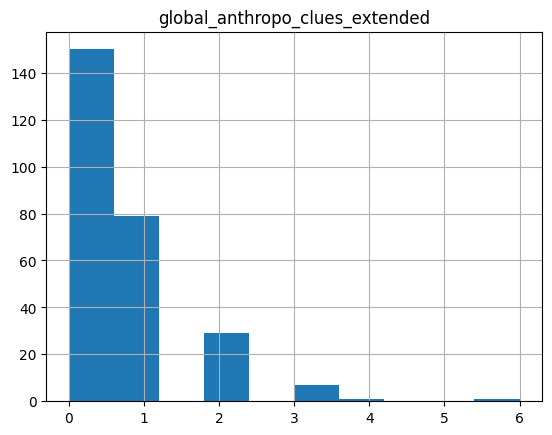

In [142]:
df.hist("global_anthropo_clues_extended")

In [143]:
df.groupby("year").value_counts(["global_anthropo_clues_extended"])[2020]

global_anthropo_clues_extended
0    10
1     7
Name: count, dtype: int64

In [144]:
years = [year for year in range(2020, 2026)]
year_counts_df = df.groupby("year").value_counts(["global_anthropo_clues_extended"])

anthropo_clues = {}

for n in range(0, 5):
    counts = []

    for year in years:
        if n in year_counts_df[year].index.tolist():
            counts.append(100 * year_counts_df[year][n] / taln_ycounts[year])
        else:
            counts.append(0)
    
    anthropo_clues[n] = counts

(0.0, 100.0)

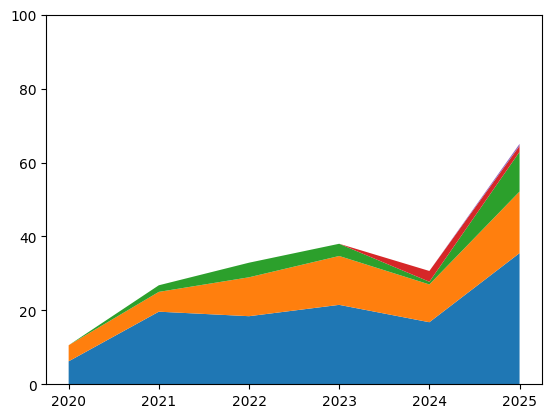

In [145]:
plt.stackplot(years, anthropo_clues[0], anthropo_clues[1], anthropo_clues[2], anthropo_clues[3], anthropo_clues[4])
plt.ylim((0, 100))

In [146]:
anthropo_binary = []
non_anthropo = []

for year in years:
    tot_llm = df[df["year"] == year].shape[0]
    print(year, tot_llm)

    anthropo_count = 0
    for n in year_counts_df[year].index.tolist():
        if n!= 0:
            anthropo_count += year_counts_df[year][n]
    print(anthropo_count)
    anthropo_binary.append(100 * anthropo_count / tot_llm)
    non_anthropo.append(100 * year_counts_df[year][0] / tot_llm)

2020 17
7
2021 15
4
2022 25
11
2023 46
20
2024 43
20
2025 121
55


In [147]:
anthropo_binary

[np.float64(41.1764705882353),
 np.float64(26.666666666666668),
 np.float64(44.0),
 np.float64(43.47826086956522),
 np.float64(46.51162790697674),
 np.float64(45.45454545454545)]

In [148]:
stats_data = []

for i, year in enumerate(years):
    row = [
        year,
        df[df["year"] == year].shape[0], # mentions LLM totales
        int(anthropo_binary[i] * df[df["year"] == year].shape[0]/100), # mentions anthropo
        int(taln_ycounts[year])
    ]
    stats_data.append(row)

In [149]:
stats_df = pd.DataFrame(stats_data, columns = ["année", "nb_mentions_LLM", "nb_mentions_LLM_anthropo", "nb_total"])
stats_df["nb_sans_LLM"] = stats_df.apply(lambda x: x["nb_total"] - x["nb_mentions_LLM"], axis = 1)
stats_df = stats_df[["année", "nb_mentions_LLM", "nb_mentions_LLM_anthropo", "nb_sans_LLM", "nb_total"]]
stats_df.to_csv("stats_corpus_CORIA_JEP_TALN_RECITAL.csv", index = False)
stats_df

,année,nb_mentions_LLM,nb_mentions_LLM_anthropo,nb_sans_LLM,nb_total
0,2020,17,7,144,161
1,2021,15,4,41,56
2,2022,25,11,51,76
3,2023,46,20,75,121
4,2024,43,20,94,137
5,2025,121,55,65,186


In [150]:
ratios = []

for i, year in enumerate(years):
    nb_llm_anthropo = stats_df.loc[i, "nb_mentions_LLM_anthropo"]
    nb_llm = stats_df.loc[i, "nb_mentions_LLM"]

    ratio = 100 * nb_llm_anthropo / nb_llm

    ratios.append(ratio)

ratios

[np.float64(41.1764705882353),
 np.float64(26.666666666666668),
 np.float64(44.0),
 np.float64(43.47826086956522),
 np.float64(46.51162790697674),
 np.float64(45.45454545454545)]

In [151]:
taln_ycounts

{2025: 186, 2020: 161, 2024: 137, 2023: 121, 2022: 76, 2021: 56}

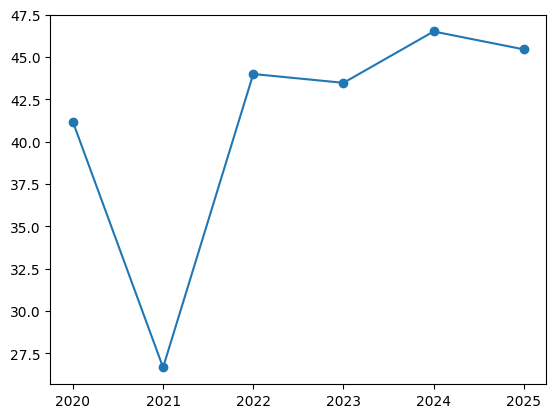

In [152]:
plt.plot(years, anthropo_binary, "o-")

In [153]:
anthropo_binary_tot = []
non_anthropo_tot = []
ratios = []

for year in years:
    anthropo_count = 0
    for n in year_counts_df[year].index.tolist():
        if n!= 0:
            anthropo_count += year_counts_df[year][n]
            
    anthropo_binary_tot.append(100 * anthropo_count /  taln_ycounts[year])
    non_anthropo_tot.append(100 * year_counts_df[year][0] /  taln_ycounts[year])
    
    ratios.append(100 * anthropo_count / (year_counts_df[year][0] + anthropo_count))
    print(year)
    print("anthropo" , 100 * anthropo_count /  taln_ycounts[year])

2020
anthropo 4.3478260869565215
2021
anthropo 7.142857142857143
2022
anthropo 14.473684210526315
2023
anthropo 16.52892561983471
2024
anthropo 14.598540145985401
2025
anthropo 29.56989247311828


In [154]:
anthropo_binary_tot

[np.float64(4.3478260869565215),
 np.float64(7.142857142857143),
 np.float64(14.473684210526315),
 np.float64(16.52892561983471),
 np.float64(14.598540145985401),
 np.float64(29.56989247311828)]

/tmp/ipykernel_9475/1478734046.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


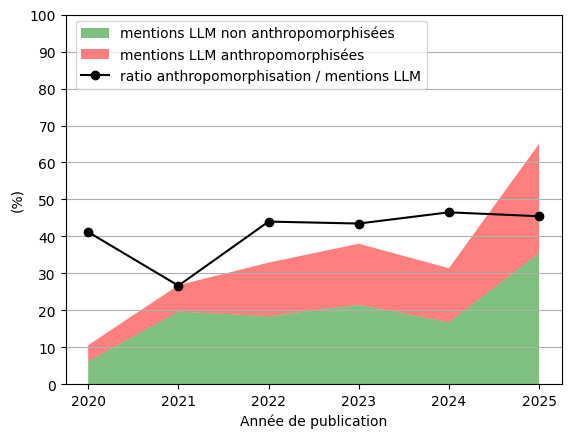

In [155]:
plt.grid(axis='y')
plt.stackplot(years, non_anthropo_tot, anthropo_binary_tot, colors = ["green", "red"], alpha = 0.5,)
plt.plot(years, ratios, "o-", color = "black")
plt.legend()
plt.ylim((0, 100))
plt.yticks([i for i in range(0,110,10)])
plt.ylabel("(%)")
plt.xlabel("Année de publication")
plt.legend(labels = ["mentions LLM non anthropomorphisées", "mentions LLM anthropomorphisées", "ratio anthropomorphisation / mentions LLM"], loc = (0.02, 0.8), fontsize = 10)
plt.savefig("anthropo_papers_taln.pdf", dpi = 300, bbox_inches = "tight")
plt.show()